In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

import matplotlib
import matplotlib.font_manager

In [2]:
#缓存（cache）装饰器
from requests import get
from functools import wraps

def check_cache(f):
    @wraps(f)
    def wrapper(src:str, dst:str, min_size=100) -> Path:
        if src.find('?') == -1:
            url = Path(src)
        else:
            url = Path(src[:src.find('?')])
        fn  = url.name  # Extract the filename
        dsn = Path(f"{dst}/{fn}") # Destination filename
        if dsn.is_file() and dsn.stat().st_size > min_size:
            print(f"+ {dsn} found locally!")
            return(dsn)
        else:
            print(f"+ {dsn} not found, downloading!")
            return(f(src, dsn))
    return wrapper

In [3]:
#下载函数
@check_cache
def cache_data(src:Path, dst:Path) -> str:
    """Downloads a remote file.
    
    The function sits between the 'read' step of a pandas or geopandas
    data frame and downloading the file from a remote location. The idea
    is that it will save it locally so that you don't need to remember to
    do so yourself. Subsequent re-reads of the file will return instantly
    rather than downloading the entire file for a second or n-th itme.
    
    Parameters
    ----------
    src : str
        The remote *source* for the file, any valid URL should work.
    dst : str
        The *destination* location to save the downloaded file.
        
    Returns
    -------
    str
        A string representing the local location of the file.
    """
      
    # Create any missing directories in dest(ination) path
    # -- os.path.join is the reverse of split (as you saw above)
    # but it doesn't work with lists... so I had to google how
    # to use the 'splat' operator! os.makedirs creates missing
    # directories in a path automatically.
    if not dst.parent.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        
    # Download and write the file
    with dst.open(mode='wb') as file:
        response = get(src)
        file.write(response.content)
        
    print(' + Done downloading...')

    return dst.resolve()

In [4]:
help(cache_data)

Help on function cache_data in module __main__:

cache_data(src: pathlib.Path, dst: pathlib.Path) -> str
    Downloads a remote file.

    The function sits between the 'read' step of a pandas or geopandas
    data frame and downloading the file from a remote location. The idea
    is that it will save it locally so that you don't need to remember to
    do so yourself. Subsequent re-reads of the file will return instantly
    rather than downloading the entire file for a second or n-th itme.

    Parameters
    ----------
    src : str
        The remote *source* for the file, any valid URL should work.
    dst : str
        The *destination* location to save the downloaded file.

    Returns
    -------
    str
        A string representing the local location of the file.



In [5]:
#下载/读取地理数据
ddir  = Path('data/geo')
spath = 'https://github.com/jreades/fsds/blob/master/data/src/' # source path

boros = gpd.read_file( cache_data(spath + 'Boroughs.gpkg?raw=true', ddir.resolve()) )

print('Done.')

+ /home/jovyan/work/The-Universe-s-Premier-F/data/geo/Boroughs.gpkg found locally!
Done.


In [6]:
# Input: date + city
ymd  = '20250615'
city = 'London'
host = "https://raw.githubusercontent.com"
repo = "yjzhou217/The-Universe-s-Premier-F/main"

url  = f"{host}/{repo}/{ymd}-{city}-listings.csv.gz"
print(url)

# 创建 data/raw 文件夹
Path("data/raw").mkdir(parents=True, exist_ok=True)

# load csv
file_path = cache_data(url, Path("data/raw").resolve())

df = pd.read_csv(file_path, compression="gzip", low_memory=False)
print(f"Data frame is {df.shape[0]:,} x {df.shape[1]}")


https://raw.githubusercontent.com/yjzhou217/The-Universe-s-Premier-F/main/20250615-London-listings.csv.gz
+ /home/jovyan/work/The-Universe-s-Premier-F/data/raw/20250615-London-listings.csv.gz found locally!
Data frame is 96,651 x 79


In [7]:
#clean csv data
#testing mode
TESTING = False

if TESTING:
    N = 10_000
else:
    N = None  # None = read all

df = pd.read_csv(
    file_path,
    nrows=N,
    low_memory=False
)

print(f"Data frame is {df.shape[0]:,} x {df.shape[1]}")

Data frame is 96,651 x 79


In [8]:
#随机抽样
df.sample(3, random_state=42)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
55322,940318502107598761,https://www.airbnb.com/rooms/940318502107598761,20250610032232,2025-06-12,city scrape,Lovely flat in West London,Calm and tranquil flat just off Portobello Roa...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,12260283,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
82794,1316092340060307099,https://www.airbnb.com/rooms/1316092340060307099,20250610032232,2025-06-14,previous scrape,Short walk from local amenities,Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,667965836,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
21163,25321683,https://www.airbnb.com/rooms/25321683,20250610032232,2025-06-13,previous scrape,"Bright, modern flat near Finsbury Park","Light, modern 1-bedroom flat situated next to ...",NaN,https://a0.muscache.com/pictures/ff89be9e-bced...,5768769,...,5.0,5.0,5.0,NaN,t,1,1,0,0,0.01


In [9]:
#clean data
#删除id缺失的行
missing_id_rows = df[df['id'].isna()][['id', "latitude", "longitude", 'room_type']]
print(f"{missing_id_rows.shape[0]:,}")
if missing_id_rows.shape[0] > 0:
    print(missing_id_rows.head())

df.drop(df[df['id'].isna()].index, axis=0, inplace=True)
print(f"{df.shape[0]:,} x {df.shape[1]}")

0
96,651 x 79


In [10]:
#寻找垃圾列
df.isnull().sum(axis=0).sort_values(ascending=False)[:12]

license                         96651
calendar_updated                96651
neighbourhood_group_cleansed    96651
neighborhood_overview           54668
neighbourhood                   54667
host_neighbourhood              50360
host_about                      47337
beds                            33975
price                           33967
estimated_revenue_l365d         33967
bathrooms                       33921
host_response_rate              33024
dtype: int64

In [11]:
#删除全是nan的列
df.drop(columns=['license','calendar_updated','neighbourhood_group_cleansed'], inplace=True)

In [12]:
#寻找垃圾行
df.isnull().sum(axis=1).sort_values(ascending=False).head(10)

6122     33
5155     33
4622     33
3646     32
30641    31
5535     31
58822    28
86012    27
87970    27
34580    27
dtype: int64

<class 'pandas.core.series.Series'>


<Axes: ylabel='Frequency'>

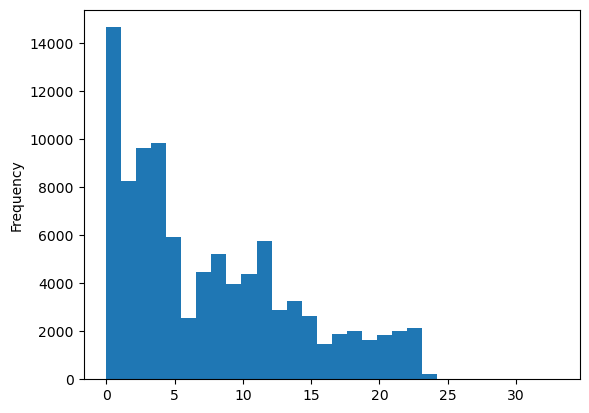

In [13]:
#绘制 histogram
probs = df.isnull().sum(axis=1)
print(type(probs))
probs.plot.hist(bins=30)

In [14]:
#考虑删除缺失超过25个值的行
print(f"df contains {df.shape[0]:,} rows.")
cutoff = 25
df.drop(probs[probs > cutoff].index, inplace=True)
print(f"df contains {df.shape[0]:,} rows.")

df contains 96,651 rows.
df contains 96,639 rows.


In [15]:
#Fixing Data Types
#把分类变量变成category，包括source、property_type、room_type、neighbourhood、neighbourhood_cleansed、host_response_time
cols_to_category = [
    'source', 'property_type', 'room_type',
    'neighbourhood', 'neighbourhood_cleansed',
    'host_response_time'
]

for col in cols_to_category:
    df[col] = df[col].astype('category')

#字符串布尔变成Boolean
bool_cols = [
    'host_has_profile_pic',
    'host_identity_verified',
    'host_is_superhost',
    'has_availability',
    'instant_bookable'
]

for col in bool_cols:
    df[col] = df[col].replace({'t': True, 'f': False}).astype(bool)

#转换日期格式
date_cols = [
    'host_since',
    'last_scraped',
    'calendar_last_scraped',
    'first_review',
    'last_review'          
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

#Dealing with Strings（price）
money = ['price']
for m in money:
    df[m] = df[m].str.replace('$','', regex=False).str.replace(',','', regex=False).astype('float')

#Dealing with Integers（处理整数列）
int_cols = [
    'id', 'host_id', 'host_listings_count', 'host_total_listings_count',
    'accommodates', 'beds', 'bedrooms', 'minimum_nights', 'maximum_nights',
    'availability_30','availability_60','availability_90','availability_365',
    'number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d','number_of_reviews_ly'
]

for col in int_cols:
    print(f"Converting {col}")
    try:
        df[col] = df[col].astype('float').astype('int')
    except ValueError as e:
        print(f"  - Warning: {col} has missing or non-integer values, converting to nullable UInt16")
        df[col] = df[col].astype('float').astype(pd.UInt16Dtype())

/tmp/ipykernel_146/1744722621.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'t': True, 'f': False}).astype(bool)


Converting id
Converting host_id
Converting host_listings_count
  - Warning: host_listings_count has missing or non-integer values, converting to nullable UInt16
Converting host_total_listings_count
  - Warning: host_total_listings_count has missing or non-integer values, converting to nullable UInt16
Converting accommodates
Converting beds
  - Warning: beds has missing or non-integer values, converting to nullable UInt16
Converting bedrooms
  - Warning: bedrooms has missing or non-integer values, converting to nullable UInt16
Converting minimum_nights
Converting maximum_nights
Converting availability_30
Converting availability_60
Converting availability_90
Converting availability_365
Converting number_of_reviews
Converting number_of_reviews_ltm
Converting number_of_reviews_l30d
Converting number_of_reviews_ly


In [25]:
#Validation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96639 entries, 0 to 96638
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            96639 non-null  int64         
 1   listing_url                                   96639 non-null  object        
 2   scrape_id                                     96639 non-null  int64         
 3   last_scraped                                  96639 non-null  datetime64[ns]
 4   source                                        96639 non-null  category      
 5   name                                          96639 non-null  object        
 6   description                                   93794 non-null  object        
 7   neighborhood_overview                         41982 non-null  object        
 8   picture_url                                   96630 non-null  obje

In [26]:
#Saving
from pathlib import Path

# 输出文件路径
csv_out = Path(f"data/clean/{file_path.name}") 
pq_out  = Path(f"data/clean/{file_path.name.replace('.csv.gz','.parquet')}")

# 创建文件夹（如果不存在）
if not csv_out.parent.exists():
    print(f"Creating folder {csv_out.parent}")
    csv_out.parent.mkdir(parents=True, exist_ok=True)

# 保存 CSV 和 Parquet
df.to_csv(csv_out, index=False)
df.to_parquet(pq_out, index=False)

print(f"Saved {df.shape[0]:,} rows of {df.shape[1]} columns to {csv_out.resolve()}")
print("Done.")

Saved 96,639 rows of 76 columns to /home/jovyan/work/The-Universe-s-Premier-F/data/clean/20250615-London-listings.csv.gz
Done.


In [27]:
#导入clean完的Parquet
parquet_path = Path("data/clean") / file_path.name.replace(".csv.gz", ".parquet")
df = pd.read_parquet(parquet_path)
print(f"Data frame is {df.shape[0]:,} x {df.shape[1]}")

Data frame is 96,639 x 76


In [28]:
#从 DataFrame 创建 GeoDataFrame（把 lon/lat 转为 geometry）
gdf = gpd.GeoDataFrame(df,
      geometry=gpd.points_from_xy(df.longitude, df.latitude, crs='epsg:4326'))

In [29]:
#保存 geo parquet
gdf.to_parquet(Path(f'data/geo/{ymd}-{city}-listings.geoparquet').resolve())
print(type(gdf))
print(type(gdf.geometry))
gdf.geometry.iloc[1:5]

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geoseries.GeoSeries'>


1    POINT (-0.01997 51.44284)
2    POINT (-0.02275 51.44359)
3    POINT (-0.02309 51.44355)
4    POINT (-0.02307 51.44333)
Name: geometry, dtype: geometry

In [30]:
#检查crs
for g in [boros, gdf]:
    print(g.crs)

EPSG:27700
epsg:4326


In [31]:
#重投影
gdf = gdf.to_crs('epsg:27700') 
print(gdf.geometry.crs)
print(gdf.total_bounds)

epsg:27700
[504186.07291139 156900.42075072 558044.54194941 200027.74372136]


In [32]:
#1.1airbnb在空间上的分布，集中在哪个区域
fontname = "Roboto Slab"

matplotlib.font_manager.FontManager().findfont(fontname, fontext='ttf', rebuild_if_missing=True)

import pysal as p
import mapclassify as mc
import palettable.matplotlib as palmpl
from legendgram import legendgram

tgdf = gdf[
    (~gdf.price.isna()) &
    (gdf.price > 0) ].copy()

print(f"Loaded: {gdf.shape[0]} rows.")
print(f"Selected: {tgdf.shape[0]} rows.")

/opt/conda/lib/python3.12/site-packages/pysal/lib/io/fileio.py:43: SyntaxWarning: invalid escape sequence '\*'
  FileIO.open(\*args) == FileIO(\*args)
/opt/conda/lib/python3.12/site-packages/pysal/lib/weights/weights.py:405: SyntaxWarning: invalid escape sequence '\s'
  s0=\sum_i \sum_j w_{i,j}
/opt/conda/lib/python3.12/site-packages/pysal/lib/weights/weights.py:419: SyntaxWarning: invalid escape sequence '\s'
  s1=1/2 \sum_i \sum_j (w_{i,j} + w_{j,i})^2
/opt/conda/lib/python3.12/site-packages/pysal/lib/weights/weights.py:451: SyntaxWarning: invalid escape sequence '\s'
  s2=\sum_j (\sum_i w_{i,j} + \sum_i w_{j,i})^2
/opt/conda/lib/python3.12/site-packages/pysal/lib/weights/weights.py:1027: SyntaxWarning: invalid escape sequence '\i'
  symmetry is defined as :math:`i \in N_j \ AND \ j \in N_i` where
/opt/conda/lib/python3.12/site-packages/pysal/lib/weights/weights.py:1357: SyntaxWarning: invalid escape sequence '\s'
  s0=\sum_i \sum_j w_{i,j}
/opt/conda/lib/python3.12/site-packages/pys

Loaded: 96639 rows.
Selected: 62678 rows.


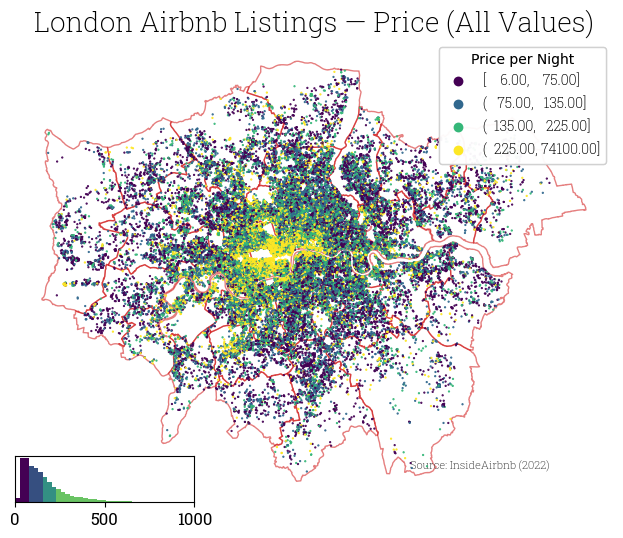

In [33]:
q = mc.Quantiles(tgdf.price.values, k=4)

tgdf['bins'] = q.yb

f,ax = plt.subplots(figsize=(8,6))
boros.plot(edgecolor=(0.8, 0, 0, 0.5), facecolor='none', linewidth=1, zorder=1, ax=ax)

ax.axis('off') 

tgdf.plot(column='bins', categorical=True,
         cmap='viridis', legend=True, marker='.', markersize=1.5, zorder=4, ax=ax)

ax.set_title('London Airbnb Listings — Price (All Values)',
             fontdict={'fontsize':'20', 'fontweight':'3', 'family':fontname}) 

for c in ax.collections:
    if c.get_zorder()==4:
        handles, _ = c.legend_elements(prop="colors")
        legend1 = ax.legend(handles, q.get_legend_classes(fmt='{:.2f}'),
                            loc="upper right", title="Price per Night",
                            prop={'size':'10', 'weight':'1', 'family':fontname})
        ax.add_artist(legend1)

a = ax.text(tgdf.geometry.x.max(), tgdf.geometry.y.min(), 'Source: InsideAirbnb (2022)',
             horizontalalignment='right', verticalalignment='bottom',
             fontsize=8, fontweight=2, color='#333333', family=fontname)

ax2 = legendgram(f, ax,
           tgdf.price, q.bins, bins=round(gdf.price.max()/25),
           pal=palmpl.Viridis_4,
           legend_size=(0.3, 0.1),
           loc='lower left',
           clip=(0,1000),
           frameon=True
    )

for tk in ax2.get_xticklabels():
    tk.set_fontname(fontname)

In [34]:
#

gdf has 96,639 rows.
The range of ln(price) is 1.9459 to 11.2132


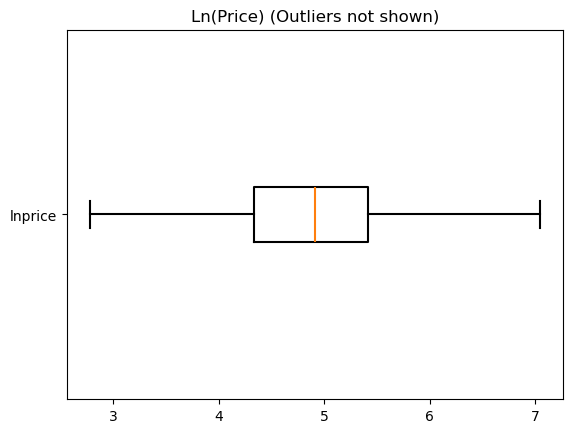

In [35]:
print(f"gdf has {gdf.shape[0]:,.0f} rows.")

gdf['lnprice'] = np.log(gdf.price + 1)

print(f"The range of ln(price) is {gdf.lnprice.min():,.4f} to {gdf.lnprice.max():,.4f}")

gdf.lnprice.plot(kind='box', vert=False,
             color=dict(boxes='r', whiskers='r', medians='r', caps='r'),
             boxprops=dict(linestyle='-', linewidth=1.5),
             flierprops=dict(linestyle='-', linewidth=1.5),
             medianprops=dict(linestyle='-', linewidth=1.5),
             whiskerprops=dict(linestyle='-', linewidth=1.5),
             capprops=dict(linestyle='-', linewidth=1.5),
             showfliers=False, grid=False, rot=0);
plt.title("Ln(Price) (Outliers not shown)")
plt.show()

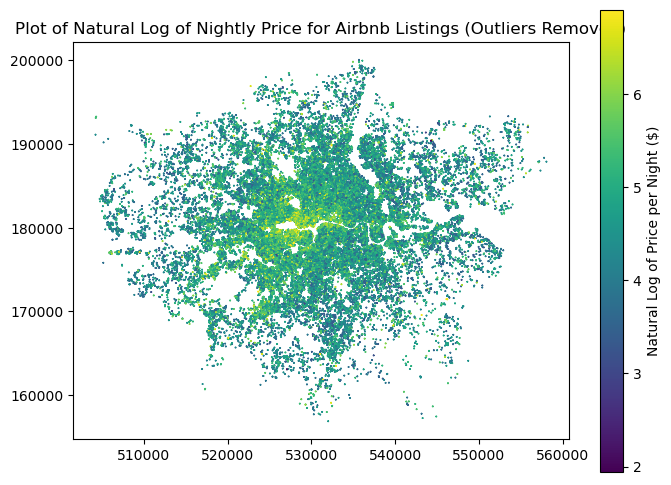

In [36]:
ax = gdf[(gdf.lnprice > 0) & (gdf.lnprice < np.log(1000))].plot(figsize=(8,6), marker='*', markersize=0.25, column='lnprice', cmap='viridis', legend=True, legend_kwds={'label':'Natural Log of Price per Night ($)'});
ax.set_title("Plot of Natural Log of Nightly Price for Airbnb Listings (Outliers Removed)");

In [37]:
#依据：三篇参考文章《Airbnb and the rent gap:Gentrification through the sharing economy》《The High Cost of 
#Short-Term Rentals》《The high cost of short-term rental in New York City》
#最终使用依据为:①room_type为 entire-home listings大于等于2（多套整套房源）或者 ≥3 private-room listings（至少三间独立房间房源）
#②name包含manage和group这些词根词缀的房子。
#两者取并集， df原始数据集是这个。 房东ID是这个host_id，房子ID是这个id

In [57]:
#Q2:
# ============================================================
# 4. 运营维度分析 (Operational Dimension)
# 定义（并集 OR）：
# ① host-level（Wachsmuth & Weisler 2018 的 commercial operator 口径）
#    - entire-home listings >= 2  OR  private-room listings >= 3
# ② name 文本线索：任一 listing 的 name 含 "manage" 或 "group" 词根
# 两者取并集：is_professional = cond1_threshold OR cond2_nameflag
# ============================================================

In [68]:
#A) 专业房东筛选（只打标）
import numpy as np
import pandas as pd
import geopandas as gpd

# 如果没有 df，就用 gdf（gdf 也有 host_id/id/name/room_type 等）
if "df" not in globals():
    df = gdf.copy()

# 1) host-level 聚合
host = (
    df.groupby("host_id")
      .agg(
          n_entire=("calculated_host_listings_count_entire_homes", "max"),
          n_private=("calculated_host_listings_count_private_rooms", "max"),
          n_listings=("id", "nunique")
      )
)

# 条件①：阈值（整套>=2 或 私房>=3）
host["cond1"] = (host["n_entire"] >= 2) | (host["n_private"] >= 3)

# 条件②：name 关键词（非捕获组，避免 warning）
pattern = r"\b(?:management|managed|property|properties|serviced|apartments?|lettings?|agency|cohost|team|group|ltd|limited|inc|plc)\b"
df["_name_hit"] = df["name"].fillna("").astype(str).str.contains(pattern, case=False, regex=True, na=False)
host["cond2"] = df.groupby("host_id")["_name_hit"].any()

# 并集：专业房东（0/1）
host["professional_landlord"] = (host["cond1"] | host["cond2"]).astype(int)

# 回填到 df2（表）
df2 = df.merge(host[["professional_landlord"]], left_on="host_id", right_index=True, how="left")
df2["professional_landlord"] = df2["professional_landlord"].fillna(0).astype(int)

# 回填到 gdf2（空间点，用于地图）
gdf2 = gdf.merge(df2[["id", "professional_landlord"]], on="id", how="left")
gdf2["professional_landlord"] = gdf2["professional_landlord"].fillna(0).astype(int)

print("Done: host / df2 / gdf2 created.")


Done: host / df2 / gdf2 created.


In [1]:
#B) 专业房东统计 + Top5 + Lorenz/Gini（只输出与画图）
import matplotlib.pyplot as plt
import numpy as np

# --- 基础统计 ---
total_hosts = host.shape[0]

# 总房源数口径：用 host 的 n_listings 总和（最一致）
holding = host["n_listings"].astype(float).fillna(0)
total_listings = int(holding.sum())

num_prof_hosts = int(host["professional_landlord"].sum())
prof_host_share = (num_prof_hosts / total_hosts * 100) if total_hosts else 0.0

# 专业房东控制的房源数（listing-level 去重）
listings_by_prof = df2.loc[df2["professional_landlord"] == 1, "id"].nunique()
prof_listing_share = (listings_by_prof / total_listings * 100) if total_listings else 0.0
print(f"总房东数: {total_hosts:,}")
print(f"专业房东数: {num_prof_hosts:,} ({prof_host_share:.1f}%)")
print(f"专业房东控制房源数: {listings_by_prof:,}")
print(f"专业房东控制份额: {prof_listing_share:.1f}%")


print(f"满足条件①阈值的房东: {int(host['cond1'].sum()):,}")
print(f"满足条件②关键词的房东: {int(host['cond2'].sum()):,}")
print(f"两者交集: {int((host['cond1'] & host['cond2']).sum()):,}")

# --- Top 5% 集中度 ---
holding_sorted = holding.sort_values()
top_n = max(1, int(np.ceil(len(holding_sorted) * 0.05)))
top_hold = float(holding_sorted.tail(top_n).sum())
top5_share = (top_hold / total_listings * 100) if total_listings else 0.0

print("\n=== 市场集中度 (Top 5%) ===")
print(f"前5%房东数量: {top_n:,}")
print(f"他们控制房源数: {int(top_hold):,}")
print(f"集中度(Top 5% share): {top5_share:.1f}%")

# --- Lorenz & Gini ---
x = holding_sorted.values.astype(float)
if x.sum() == 0:
    print("\nGini: NA (no listings)")
else:
    x_sorted = np.sort(x)
    cum_x = np.cumsum(x_sorted) / x_sorted.sum()
    cum_p = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

    cum_x = np.insert(cum_x, 0, 0)
    cum_p = np.insert(cum_p, 0, 0)

    area = np.trapz(cum_x, cum_p)
    gini = (0.5 - area) / 0.5

    plt.figure(figsize=(7, 7))
    plt.plot(cum_p, cum_x, linewidth=2, label="Lorenz Curve")
    plt.plot([0, 1], [0, 1], "k--", label="Line of Equality")
    plt.title(f"Lorenz Curve of Listing Ownership (Gini={gini:.2f})")
    plt.xlabel("Cumulative % of Hosts")
    plt.ylabel("Cumulative % of Listings")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nGini: {gini:.3f}")


NameError: name 'host' is not defined

In [70]:
#Q3:受影响的房源

In [71]:
#1找到受影响的房源
#2受影响房源占总的比例
#3按行政区（neighbourhood_cleansed）统计受影响 listings数量
#4受影响房源的房源类型
#5受影响房源的空间分布

In [72]:
#B0) 定义“受影响房源”（专业房东名下所有房源
import matplotlib.pyplot as plt

affected_gdf = gdf2[gdf2["professional_landlord"] == 1].copy()


In [62]:
#B1) #1 受影响房源数目 & #2 占总房源比例
total_listings = gdf2["id"].nunique()
affected_listings = affected_gdf["id"].nunique()
affected_share = (affected_listings / total_listings * 100) if total_listings else 0.0

print("#1 受影响房源数（专业房东名下所有房源）:", f"{affected_listings:,}")
print("#2 受影响房源占总房源比例:", f"{affected_share:.2f}%")


#1 受影响房源数（专业房东名下所有房源）: 49,081
#2 受影响房源占总房源比例: 50.79%


In [63]:
#B2) #3 按 borough 统计受影响 listings 数量（全表、降序）
# CRS 对齐：sjoin 要同 CRS
if (affected_gdf.crs is not None) and (boros.crs is not None) and (affected_gdf.crs != boros.crs):
    affected_gdf = affected_gdf.to_crs(boros.crs)

# sjoin（兼容新旧 geopandas）
try:
    affected_boro = gpd.sjoin(
        affected_gdf,
        boros[["NAME", "geometry"]],
        how="left",
        predicate="within"
    )
except TypeError:
    affected_boro = gpd.sjoin(
        affected_gdf,
        boros[["NAME", "geometry"]],
        how="left",
        op="within"
    )

affected_by_boro = (
    affected_boro.groupby("NAME")
    .size()
    .reset_index(name="n_affected")
)

import pandas as pd
from IPython.display import display

# 合并回所有 borough（无值填 0）
boros_affected = boros.merge(affected_by_boro, on="NAME", how="left")
boros_affected["n_affected"] = boros_affected["n_affected"].fillna(0).astype(int)

boro_table = (
    boros_affected[["NAME", "n_affected"]]
    .sort_values("n_affected", ascending=False)
    .reset_index(drop=True)
)

# 显示设置（可选）
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print("\n#3 各 Borough 受影响房源数量（降序，全表）：")

# ✅ NAME 自动换行（双行/多行）
display(
    boro_table.style
      .set_properties(subset=["NAME"], **{
          "white-space": "normal",
          "width": "180px"
      })
)



#3 各 Borough 受影响房源数量（降序，全表）：


,NAME,n_affected
0,Westminster,8601
1,Kensington and Chelsea,4444
2,Camden,4214
3,Tower Hamlets,4059
4,Southwark,2390
5,Islington,2330
6,Hammersmith and Fulham,2209
7,Hackney,2202
8,Lambeth,2077
9,Wandsworth,1933


In [53]:
#B3) #4 受影响房源的房源类型（room_type 分布表）
roomtype_table = (
    affected_gdf["room_type"]
    .value_counts(dropna=False)
    .rename_axis("room_type")
    .reset_index(name="count")
)
roomtype_table["share_%"] = roomtype_table["count"] / roomtype_table["count"].sum() * 100

print("\n#4 受影响房源的房源类型分布：")
try:
    display(roomtype_table)
except NameError:
    print(roomtype_table.to_string(index=False))



#4 受影响房源的房源类型分布：


,room_type,count,share_%
0,Entire home/apt,36842,75.063670
1,Private room,12084,24.620525
2,Shared room,84,0.171146
3,Hotel room,71,0.144659


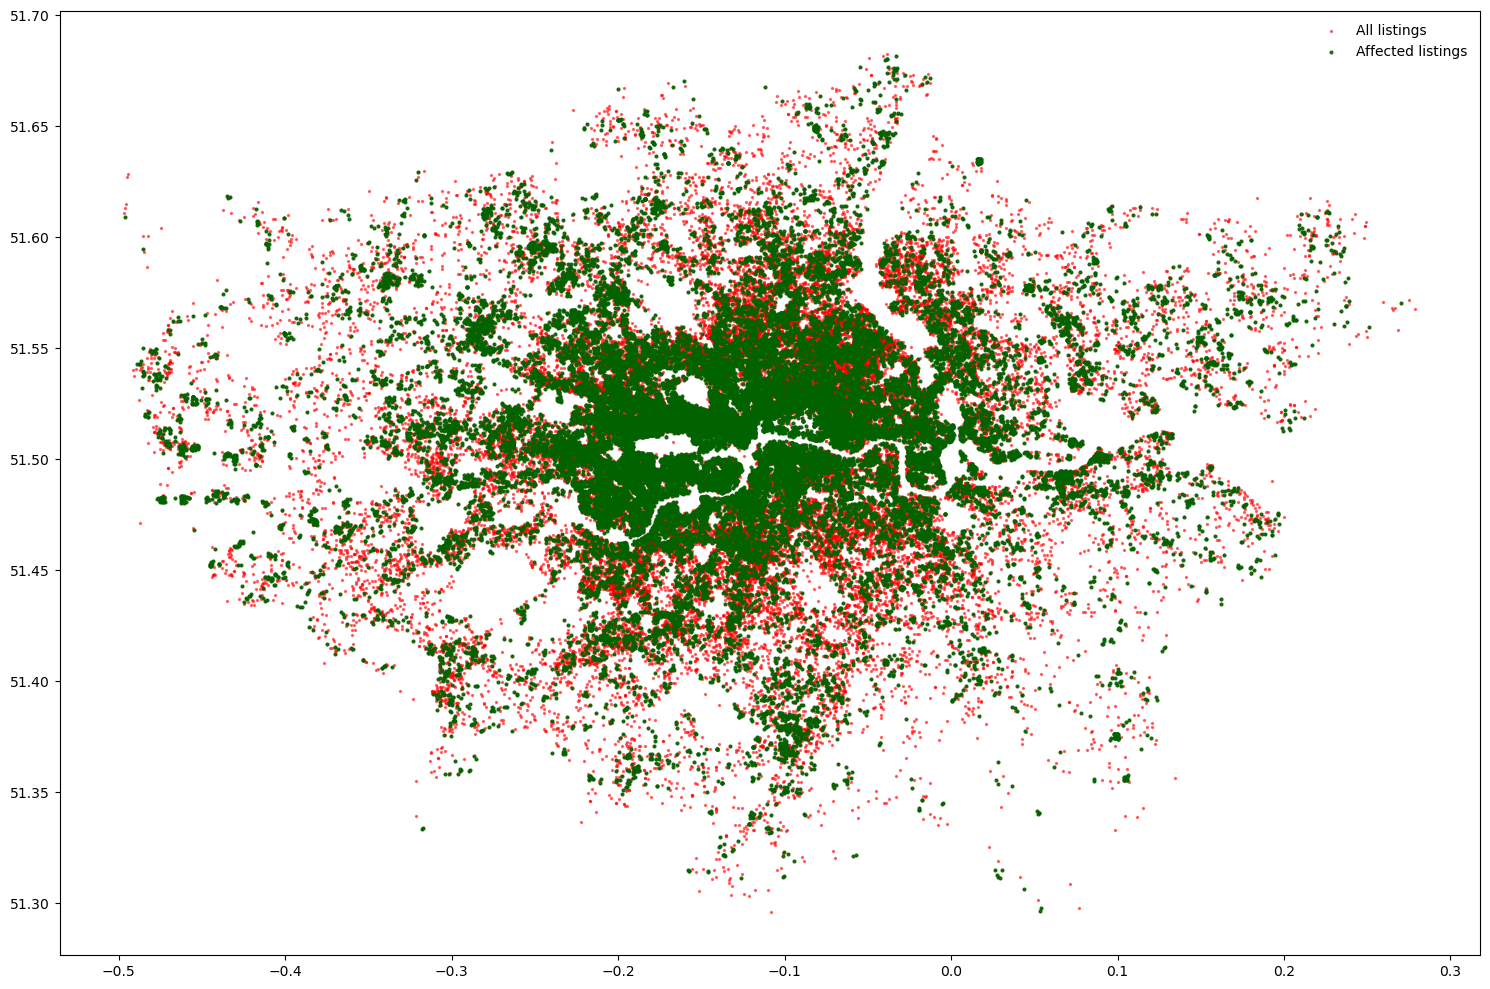

In [54]:
#①：空间对比散点图（All vs Affected）
fig, ax = plt.subplots(figsize=(15, 10))

gdf2.plot.scatter(
    x="longitude", y="latitude",
    s=2, color="red", alpha=0.5,
    ax=ax, label="All listings"
)

affected_gdf.plot.scatter(
    x="longitude", y="latitude",
    s=4, color="#006400", alpha=0.8,
    ax=ax, label="Affected listings"
)

ax.legend(frameon=False)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


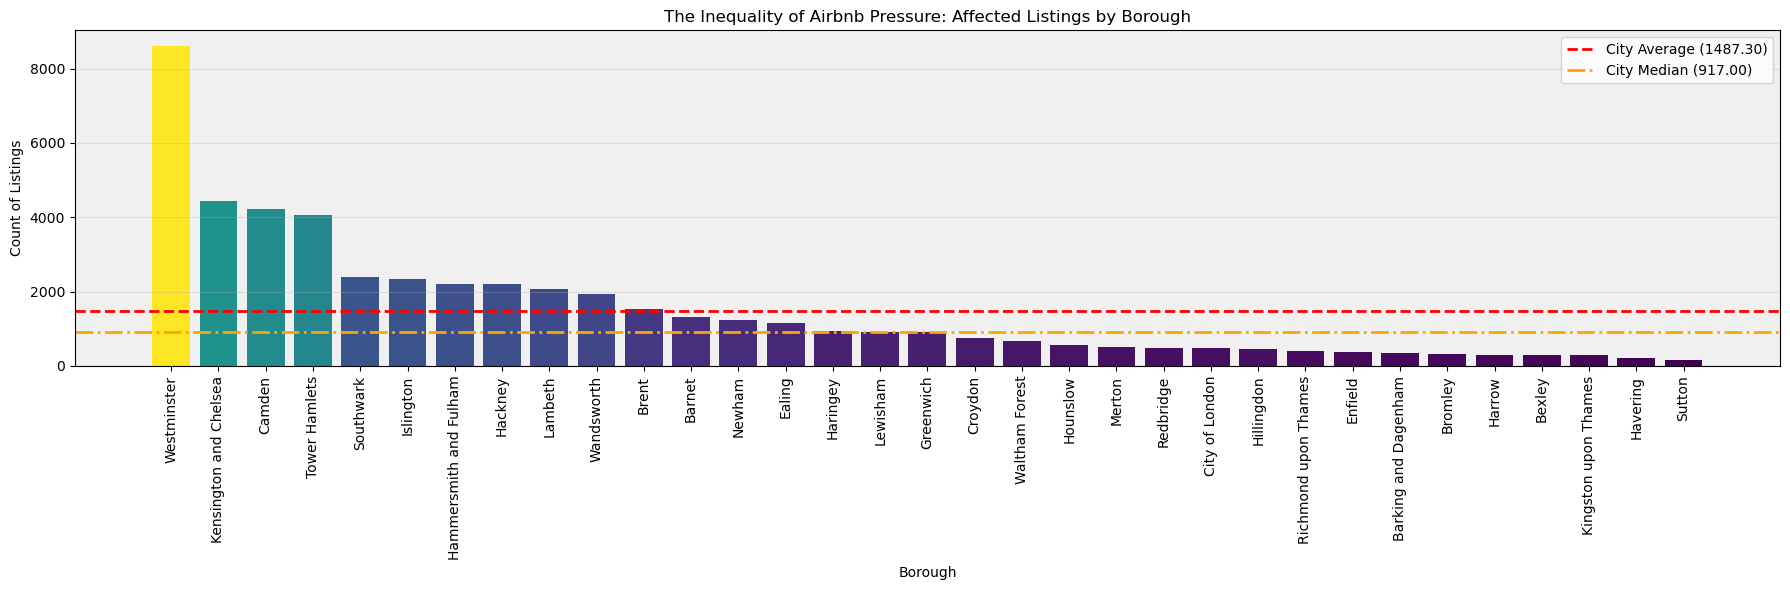

In [55]:
#②：Borough 汇总柱状图
metric = "count"   # 改成 "density" 就是每公顷密度（更像你截图）

plot_df = boro_table.copy()

if metric == "density":
    # 计算 borough 面积（ha），需要投影 CRS；优先用 EPSG:27700
    boros_proj = boros_affected.copy()
    if boros_proj.crs is None or boros_proj.crs.to_epsg() != 27700:
        boros_proj = boros_proj.to_crs(epsg=27700)

    boros_proj["area_ha"] = boros_proj.geometry.area / 10000.0
    boros_proj["density"] = boros_proj["n_affected"] / boros_proj["area_ha"]

    plot_df = boros_proj[["NAME", "density"]].sort_values("density", ascending=False).reset_index(drop=True)
    values = plot_df["density"].values
    ylab = "Density (Listings per Hectare)"
else:
    values = plot_df["n_affected"].values
    ylab = "Count of Listings"

# 渐变色（viridis，接近你截图那种紫→绿→黄）
norm = plt.Normalize(vmin=float(values.min()), vmax=float(values.max()) if values.max() > values.min() else float(values.min()+1))
colors = plt.cm.viridis(norm(values))

mean_val = float(values.mean())
median_val = float(np.median(values))

fig, ax = plt.subplots(figsize=(18, 6))
ax.set_facecolor("#f0f0f0")

ax.bar(plot_df["NAME"], values, color=colors)

ax.axhline(mean_val, linestyle="--", linewidth=2, color="red", label=f"City Average ({mean_val:.2f})")
ax.axhline(median_val, linestyle="-.", linewidth=2, color="orange", label=f"City Median ({median_val:.2f})")

ax.set_title("The Inequality of Airbnb Pressure: Affected Listings by Borough")
ax.set_ylabel(ylab)
ax.set_xlabel("Borough")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right", frameon=True)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


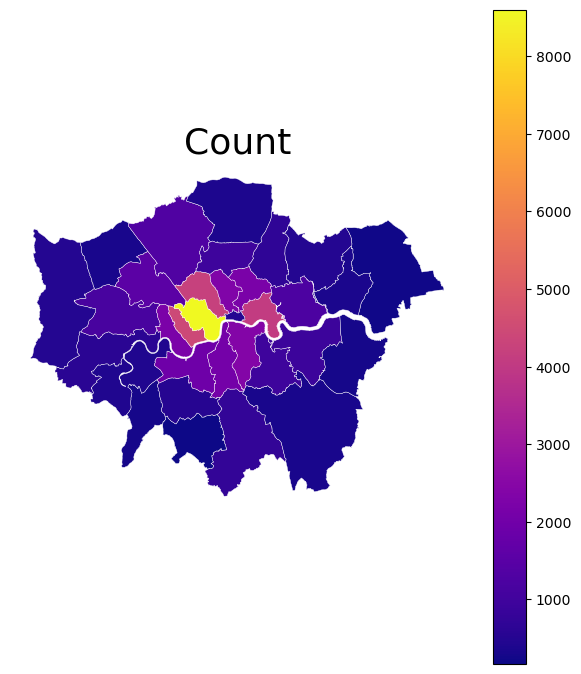

In [56]:
#③：受影响房源空间分布（borough 单元地图）
fig, ax = plt.subplots(figsize=(6, 8))

boros_affected.plot(
    column="n_affected",
    cmap="plasma",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={"shrink": 0.85},
    ax=ax
)

ax.set_axis_off()
ax.set_title("Count", fontsize=26)
plt.tight_layout()
plt.show()
